# Análise Exploratória de Dados (EDA): Detecção de Severidade em Acidentes de Trânsito do ano 2020

**Equipe 01:**
- Adriely Natasha Martins Andrade
- Hilton Alves Nery
- Miguel Luiz Lins de Oliveira
- Maria Gabriela da Silva Pereira
- Matheus Leonardo Araujo de Mesquita Silva


**Docente:** Jonathan da Silva Bandeira


**Tema:** Detecção de severidade em acidentes de trânsito

**Data de Entrega:** 13/03 (Análise) | **Apresentação:** 20/03

## 1. Configuração e Carregamento dos Dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    Normalizer,
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    QuantileTransformer,
    PowerTransformer
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.utils import resample

from scipy import stats

In [ ]:
# Carregando o dataset
dados = 'Análise de Detecção de Severidade em Acidentes de Trânsito.csv'
dados = pd.read_csv(dados, sep=';', encoding='iso-8859-1')

# Limpeza inicial de nomes de colunas (remover espaços extras e converter para minúsculas)
dados.columns = [col.strip() for col in dados.columns]
dados.columns = [col.lower() for col in dados.columns]
display(dados.head())
print("\n\n")
display(dados.tail())
print("\n\n")
display(dados.sample(5))

,num_boletim,data_hora_boletim,nº_envolvido,condutor,cod_severidade,desc_severidade,sexo,cinto_seguranca,embreagues,idade,nascimento,categoria_habilitacao,descricao_habilitacao,declaracao_obito,cod_severidade_antiga,especie_veiculo,pedestre,passageiro
0,2020-014152383-001,20/03/2020 02:18,1,S,1,NAO FATAL,M,NÃO,NÃO,35,06/09/1984,B,"VEICULOS MOTOR. COM ATE 8 PASSAGEIROS, PESO MA...",0,0,BICICLETA,N,N
1,2020-014152383-001,20/03/2020 02:18,2,S,3,SEM FERIMENTOS,F,SIM,SIM,42,11/03/1978,N,NAO INFORMADO ...,0,0,AUTOMOVEL,N,N
2,2020-014152383-001,20/03/2020 02:18,3,N,3,SEM FERIMENTOS,M,SIM,NÃO,32,20/11/1987,,...,0,0,AUTOMOVEL,N,S
3,2020-014158612-001,20/03/2020 05:39,1,N,1,NAO FATAL,F,SIM,NÃO,72,29/06/1947,,...,0,0,ONIBUS,N,S
4,2020-014158612-001,20/03/2020 05:39,2,S,3,SEM FERIMENTOS,M,SIM,NÃO,55,13/03/1965,N,NAO INFORMADO ...,0,0,ONIBUS,N,N


,num_boletim,data_hora_boletim,nº_envolvido,condutor,cod_severidade,desc_severidade,sexo,cinto_seguranca,embreagues,idade,nascimento,categoria_habilitacao,descricao_habilitacao,declaracao_obito,cod_severidade_antiga,especie_veiculo,pedestre,passageiro
22638,2020-060019495-001,14/12/2020 10:15,1,S,3,SEM FERIMENTOS,M,SIM,NÃO,34,14/07/1986,B,"VEICULOS MOTOR. COM ATE 8 PASSAGEIROS, PESO MA...",0,0,AUTOMOVEL,N,N
22639,2020-060019495-001,14/12/2020 10:15,2,S,1,NAO FATAL,M,SIM,NÃO,23,20/06/1997,A,"VEÍCULO MOTORIZ. DE 2 OU 3 RODAS, C/ OU S/ CAR...",0,0,MOTOCICLETA,NaN,NaN
22640,2020-060019495-001,14/12/2020 10:15,3,S,3,SEM FERIMENTOS,M,SIM,NÃO,36,13/03/1984,E,"CONJ. VEICULOS ACOPLADOS,QUE NAO SE INCLUE NAS...",0,0,ONIBUS,N,N
22641,2020-060029999-001,13/12/2020 16:20,1,S,3,SEM FERIMENTOS,M,SIM,NÃO,24,13/02/1996,B,"VEICULOS MOTOR. COM ATE 8 PASSAGEIROS, PESO MA...",0,0,AUTOMOVEL,N,N
22642,2020-060029999-001,13/12/2020 16:20,2,S,1,NAO FATAL,M,SIM,NÃO,26,00/00/0000,B,"VEICULOS MOTOR. COM ATE 8 PASSAGEIROS, PESO MA...",0,0,MOTOCICLETA,NaN,NaN


,num_boletim,data_hora_boletim,nº_envolvido,condutor,cod_severidade,desc_severidade,sexo,cinto_seguranca,embreagues,idade,nascimento,categoria_habilitacao,descricao_habilitacao,declaracao_obito,cod_severidade_antiga,especie_veiculo,pedestre,passageiro
20686,2020-061349247-001,22/12/2020 06:49,3,N,1,NAO FATAL,M,SIM,NÃO,22,27/05/1998,,...,0,0,MOTOCICLETA,N,S
5196,2020-005305250-001,31/01/2020 12:47,3,S,3,SEM FERIMENTOS,M,SIM,NÃO,39,20/09/1980,AB,HABILITADO NAS CATEGORIAS A e B ...,0,0,AUTOMOVEL,N,N
16396,2020-027103970-001,07/06/2020 14:31,1,S,1,NAO FATAL,M,SIM,NÃO,23,08/08/1996,A,"VEÍCULO MOTORIZ. DE 2 OU 3 RODAS, C/ OU S/ CAR...",0,0,MOTOCICLETA,N,N
16256,2020-035333082-001,23/07/2020 08:57,2,S,3,SEM FERIMENTOS,M,SIM,NÃO,65,06/10/1954,B,"VEICULOS MOTOR. COM ATE 8 PASSAGEIROS, PESO MA...",0,0,AUTOMOVEL,N,N
15761,2020-026753034-001,05/06/2020 12:35,2,S,3,SEM FERIMENTOS,F,SIM,NÃO,32,27/08/1987,B,"VEICULOS MOTOR. COM ATE 8 PASSAGEIROS, PESO MA...",0,0,AUTOMOVEL,N,N


## 2. Inspeção e Limpeza de Dados
Nesta etapa, verificamos tipos de dados, valores ausentes e consistência das variáveis.

In [ ]:
# Informações gerais sobre as colunas
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22643 entries, 0 to 22642
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   num_boletim            22643 non-null  object
 1   data_hora_boletim      22643 non-null  object
 2   nº_envolvido           22643 non-null  int64 
 3   condutor               22643 non-null  object
 4   cod_severidade         22643 non-null  int64 
 5   desc_severidade        22643 non-null  object
 6   sexo                   22643 non-null  object
 7   cinto_seguranca        22643 non-null  object
 8   embreagues             22643 non-null  object
 9   idade                  22643 non-null  int64 
 10  nascimento             22643 non-null  object
 11  categoria_habilitacao  22643 non-null  object
 12  descricao_habilitacao  22643 non-null  object
 13  declaracao_obito       22643 non-null  int64 
 14  cod_severidade_antiga  22643 non-null  int64 
 15  especie_veiculo    

In [ ]:
#Verificação de Valores Categóricos

# Valores Únicos das Variáveis Categóricas
print(dados["sexo"].unique())
print(dados["cinto_seguranca"].unique())
print(dados["embreagues"].unique())
print(dados["pedestre"].unique())
print(dados["passageiro"].unique())
print(dados["condutor"].unique())
print("\n")


# Contagem de Valores Únicos (Variáveis Categóricas)
print(dados["cod_severidade_antiga"].value_counts())
print("\n\n")

# Verificação de Possíveis Inconsistências Numéricas
verificador_01 = dados[(dados["idade"] < 0) | (dados["idade"] > 100)]
print(verificador_01)

['M' 'F' '0']
['NÃO' 'SIM']
['NÃO' 'SIM' 'NÃO INFORMADO']
['N' 'S' nan]
['N' 'S' nan]
['S' 'N']


cod_severidade_antiga
0    22643
Name: count, dtype: int64



Empty DataFrame
Columns: [num_boletim, data_hora_boletim, nº_envolvido, condutor, cod_severidade, desc_severidade, sexo, cinto_seguranca, embreagues, idade, nascimento, categoria_habilitacao, descricao_habilitacao, declaracao_obito, cod_severidade_antiga, especie_veiculo, pedestre, passageiro]
Index: []


In [ ]:
#Verificação de Valores Categóricos

# Valores Únicos das Variáveis Categóricas
print(dados["sexo"].unique())
print(dados["cinto_seguranca"].unique())
print(dados["embreagues"].unique())
print(dados["pedestre"].unique())
print(dados["passageiro"].unique())
print(dados["condutor"].unique())
print("\n")


# Contagem de Valores Únicos (Variáveis Categóricas)
print(dados["cod_severidade_antiga"].value_counts())
print("\n\n")

# Verificação de Possíveis Inconsistências Numéricas
verificador_01 = dados[(dados["idade"] < 0) | (dados["idade"] > 100)]
print(verificador_01)

['M' 'F' '0']
['NÃO' 'SIM']
['NÃO' 'SIM' 'NÃO INFORMADO']
['N' 'S' nan]
['N' 'S' nan]
['S' 'N']


cod_severidade_antiga
0    22643
Name: count, dtype: int64



Empty DataFrame
Columns: [num_boletim, data_hora_boletim, nº_envolvido, condutor, cod_severidade, desc_severidade, sexo, cinto_seguranca, embreagues, idade, nascimento, categoria_habilitacao, descricao_habilitacao, declaracao_obito, cod_severidade_antiga, especie_veiculo, pedestre, passageiro]
Index: []


In [ ]:
# Verificação de valores nulos

display(dados.isnull().sum())

# Dados Ausentes (Percentual)
print("----------------Porcentagem------------------")
missing_percent = dados.isnull().mean() * 100
print(missing_percent.sort_values(ascending=True))
print("\n\n")


,0
num_boletim,0
data_hora_boletim,0
nº_envolvido,0
condutor,0
cod_severidade,0
desc_severidade,0
sexo,0
cinto_seguranca,0
embreagues,0
idade,0


----------------Porcentagem------------------
num_boletim              0.000000
data_hora_boletim        0.000000
nº_envolvido             0.000000
condutor                 0.000000
cod_severidade           0.000000
desc_severidade          0.000000
sexo                     0.000000
cinto_seguranca          0.000000
embreagues               0.000000
idade                    0.000000
nascimento               0.000000
categoria_habilitacao    0.000000
descricao_habilitacao    0.000000
declaracao_obito         0.000000
cod_severidade_antiga    0.000000
especie_veiculo          0.000000
passageiro               9.031489
pedestre                 9.512874
dtype: float64





In [ ]:
# Mapeamento das categorias de severidade
# Primeiro removemos espaços em branco extras que podem impedir o mapeamento correto
dados['desc_severidade'] = dados['desc_severidade'].str.strip()

mapeamento = {
    'FATAL': 'Crítico',
    'NAO FATAL': 'Moderado',
    'SEM FERIMENTOS': 'Leve'
}

# Aplicando a mudança permanentemente
dados['desc_severidade'] = dados['desc_severidade'].map(mapeamento).fillna(dados['desc_severidade'])

# Verificando os novos valores únicos
print("Novos valores na coluna desc_severidade:")
print(dados['desc_severidade'].unique())

Novos valores na coluna desc_severidade:
['Moderado' 'Leve' 'NAO INFORMADO' 'Crítico']


In [ ]:
# Informações gerais sobre as colunas
dados.describe(include = 'object')

,num_boletim,data_hora_boletim,condutor,desc_severidade,sexo,cinto_seguranca,embreagues,nascimento,categoria_habilitacao,descricao_habilitacao,especie_veiculo,pedestre,passageiro
count,22643,22643,22643,22643,22643,22643,22643,22643,22643,22643,22643,20489,20598
unique,10624,10456,2,4,3,2,3,12042,14,14,22,2,2
top,2020-014233487-001,20/03/2020 16:07,S,Moderado,M,SIM,NÃO,00/00/0000,AB,HABILITADO NAS CATEGORIAS A e B ...,AUTOMOVEL,N,N
freq,17,17,19178,12544,17351,19583,20944,1504,5413,5413,9769,19284,18345


In [ ]:
# Informações gerais sobre as colunas
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22643 entries, 0 to 22642
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   num_boletim            22643 non-null  object
 1   data_hora_boletim      22643 non-null  object
 2   nº_envolvido           22643 non-null  int64 
 3   condutor               22643 non-null  object
 4   cod_severidade         22643 non-null  int64 
 5   desc_severidade        22643 non-null  object
 6   sexo                   22643 non-null  object
 7   cinto_seguranca        22643 non-null  object
 8   embreagues             22643 non-null  object
 9   idade                  22643 non-null  int64 
 10  nascimento             22643 non-null  object
 11  categoria_habilitacao  22643 non-null  object
 12  descricao_habilitacao  22643 non-null  object
 13  declaracao_obito       22643 non-null  int64 
 14  cod_severidade_antiga  22643 non-null  int64 
 15  especie_veiculo    

In [ ]:
# Verificação de valores nulos

display(dados.isnull().sum())

# Dados Ausentes (Percentual)
print("----------------Porcentagem------------------")
missing_percent = dados.isnull().mean() * 100
print(missing_percent.sort_values(ascending=True))
print("\n\n")


,0
num_boletim,0
data_hora_boletim,0
nº_envolvido,0
condutor,0
cod_severidade,0
desc_severidade,0
sexo,0
cinto_seguranca,0
embreagues,0
idade,0


----------------Porcentagem------------------
num_boletim              0.000000
data_hora_boletim        0.000000
nº_envolvido             0.000000
condutor                 0.000000
cod_severidade           0.000000
desc_severidade          0.000000
sexo                     0.000000
cinto_seguranca          0.000000
embreagues               0.000000
idade                    0.000000
nascimento               0.000000
categoria_habilitacao    0.000000
descricao_habilitacao    0.000000
declaracao_obito         0.000000
cod_severidade_antiga    0.000000
especie_veiculo          0.000000
passageiro               9.031489
pedestre                 9.512874
dtype: float64





In [ ]:
#Verificação de Valores Categóricos

# Valores Únicos das Variáveis Categóricas
print(dados["sexo"].unique())
print(dados["cinto_seguranca"].unique())
print(dados["embreagues"].unique())
print(dados["pedestre"].unique())
print(dados["passageiro"].unique())
print(dados["condutor"].unique())
print(dados["desc_severidade"].unique())
print(dados["especie_veiculo"].unique())
print("\n")


# Contagem de Valores Únicos (Variáveis Categóricas)
#print(dados["cod_severidade_antiga"].value_counts())
print("\n\n")

# Verificação de Possíveis Inconsistências Numéricas
verificador_01 = dados[(dados["idade"] < 0) | (dados["idade"] > 100)]
print(verificador_01)

['M' 'F' '0']
['NÃO' 'SIM']
['NÃO' 'SIM' 'NÃO INFORMADO']
['N' 'S' nan]
['N' 'S' nan]
['S' 'N']
['Moderado' 'Leve' 'NAO INFORMADO' 'Crítico']
['BICICLETA                     ' 'AUTOMOVEL                     '
 'ONIBUS                        ' 'MOTOCICLETA                   '
 'CAMIONETA                     ' 'CAMINHONETE                   '
 'NAO INFORMADO                 ' 'CAMINHAO                      '
 '                              ' 'CAMINHAO-TRATOR               '
 'MICROONIBUS                   ' 'MOTONETA                      '
 'REBOQUE E SEMI-REBOQUE        ' 'PATINETE                      '
 'KOMBI                         ' 'CICLOMOTOR                    '
 'CARROCA                       ' 'TRATOR MISTO                  '
 'BONDE                         ' 'CARRO DE MAO                  '
 'TRICICLO                      ' 'TRATOR DE RODAS               ']





Empty DataFrame
Columns: [num_boletim, data_hora_boletim, nº_envolvido, condutor, cod_severidade, desc_severidade, 

In [ ]:
# Tratamento básico: converter data_hora_boletim para datetime
dados['data_hora_boletim'] = pd.to_datetime(dados['data_hora_boletim'], format='%d/%m/%Y %H:%M', errors='coerce')
dados['hora'] = dados['data_hora_boletim'].dt.hour
dados['dia_semana'] = dados['data_hora_boletim'].dt.day_name()

In [ ]:
# Distribuição de Acidentes por Turno
#Vamos visualizar a distribuição da coluna `turno` para entender em quais períodos do dia a maioria dos acidentes ocorre.
#Criação de uma nova coluna para Turno

def definir_turno(hora):
    if 4 <= hora <= 11:
        return 'Manhã'
    elif 12 <= hora <= 17:
        return 'Tarde'
    else:
        return 'Noite'

dados['turno'] = dados['hora'].apply(definir_turno)

# Verificando a criação da coluna
display(dados[['hora', 'turno']].head(10))

,hora,turno
0,2,Noite
1,2,Noite
2,2,Noite
3,5,Manhã
4,5,Manhã
5,6,Manhã
6,6,Manhã
7,6,Manhã
8,7,Manhã
9,7,Manhã


In [ ]:
# Verificando variáveis

display(dados["cod_severidade_antiga"].value_counts())
print("\n\n")
#Coluna sem utilidade.

display(dados["declaracao_obito"].value_counts())
#Ninguém morreu!

,count
cod_severidade_antiga,
0,22643


,count
declaracao_obito,
0,22643


In [ ]:
# Eliminação Manual de Atributos Desnecessários e redundantes

colunas = ["cod_severidade_antiga", "nº_envolvido", "nascimento", "num_boletim", "descricao_habilitacao"]
dados = dados.drop(columns=colunas, axis=1)
display(dados.sample(5))

,data_hora_boletim,condutor,cod_severidade,desc_severidade,sexo,cinto_seguranca,embreagues,idade,categoria_habilitacao,declaracao_obito,especie_veiculo,pedestre,passageiro,hora,dia_semana,turno
18783,2020-12-17 10:53:00,S,3,Leve,M,SIM,NÃO,47,N,0,AUTOMOVEL,N,N,10,Thursday,Manhã
16936,2020-07-26 19:50:00,N,1,Moderado,F,SIM,NÃO,24,,0,MOTOCICLETA,N,S,19,Sunday,Noite
4128,2020-03-16 21:00:00,S,3,Leve,M,SIM,NÃO,29,AD,0,MOTOCICLETA,N,N,21,Monday,Noite
18853,2020-10-21 17:48:00,S,1,Moderado,M,SIM,NÃO,22,N,0,MOTOCICLETA,N,N,17,Wednesday,Tarde
15908,2020-07-06 20:00:00,S,1,Moderado,M,SIM,NÃO,31,AB,0,MOTOCICLETA,N,N,20,Monday,Noite


In [ ]:
#Eliminação de registros 'NAO INFORMADO', espaço vazio e 0.

dados = dados.drop(dados[dados['desc_severidade'] == 'NAO INFORMADO'].index)

dados = dados.drop(dados[dados['sexo'] == '0'].index)

dados = dados.drop(dados[dados['embreagues'] == 'NÃO INFORMADO'].index)

dados = dados.drop(dados[dados['especie_veiculo'] == 'NAO INFORMADO                 '].index)

dados = dados.drop(dados[dados['especie_veiculo'] == '                              '].index)

In [ ]:
print(dados["especie_veiculo"].unique())

['BICICLETA                     ' 'AUTOMOVEL                     '
 'ONIBUS                        ' 'MOTOCICLETA                   '
 'CAMIONETA                     ' 'CAMINHONETE                   '
 'CAMINHAO                      ' 'CAMINHAO-TRATOR               '
 'MICROONIBUS                   ' 'MOTONETA                      '
 'REBOQUE E SEMI-REBOQUE        ' 'PATINETE                      '
 'CICLOMOTOR                    ' 'KOMBI                         '
 'CARROCA                       ' 'TRATOR MISTO                  '
 'CARRO DE MAO                  ' 'TRATOR DE RODAS               '
 'TRICICLO                      ' 'BONDE                         ']


In [ ]:
#Após todas as modificações, visualizar a tabela nova
display(dados.sample(5))

,data_hora_boletim,condutor,cod_severidade,desc_severidade,sexo,cinto_seguranca,embreagues,idade,categoria_habilitacao,declaracao_obito,especie_veiculo,pedestre,passageiro,hora,dia_semana,turno
2301,2020-03-28 11:58:00,S,3,Leve,M,SIM,NÃO,36,B,0,AUTOMOVEL,N,N,11,Saturday,Manhã
14421,2020-05-05 17:43:00,S,1,Moderado,M,SIM,NÃO,28,AB,0,MOTOCICLETA,N,N,17,Tuesday,Tarde
6008,2020-01-16 15:23:00,S,1,Moderado,M,SIM,NÃO,24,N,0,MOTOCICLETA,N,N,15,Thursday,Tarde
2500,2020-02-27 19:21:00,S,1,Moderado,M,SIM,NÃO,46,AB,0,MOTOCICLETA,N,N,19,Thursday,Noite
3926,2020-03-28 21:40:00,S,1,Moderado,M,SIM,NÃO,22,N,0,MOTOCICLETA,N,N,21,Saturday,Noite


## 3. Análise da Variável Alvo: Severidade
A variável `desc_severidade` é o nosso alvo principal.

/tmp/ipykernel_408/142994936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x='desc_severidade', palette='viridis')


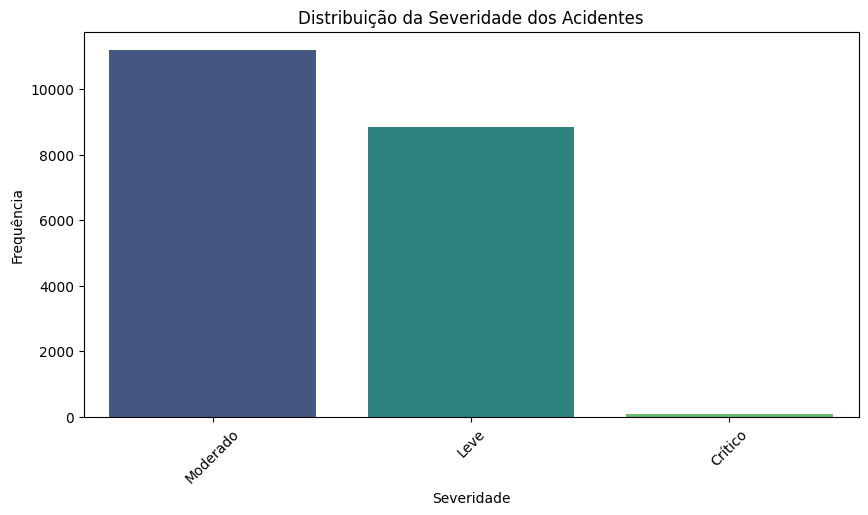

In [ ]:
# Distribuição da severidade
plt.figure(figsize=(10, 5))
sns.countplot(data=dados, x='desc_severidade', palette='viridis')
plt.title('Distribuição da Severidade dos Acidentes')
plt.xlabel('Severidade')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

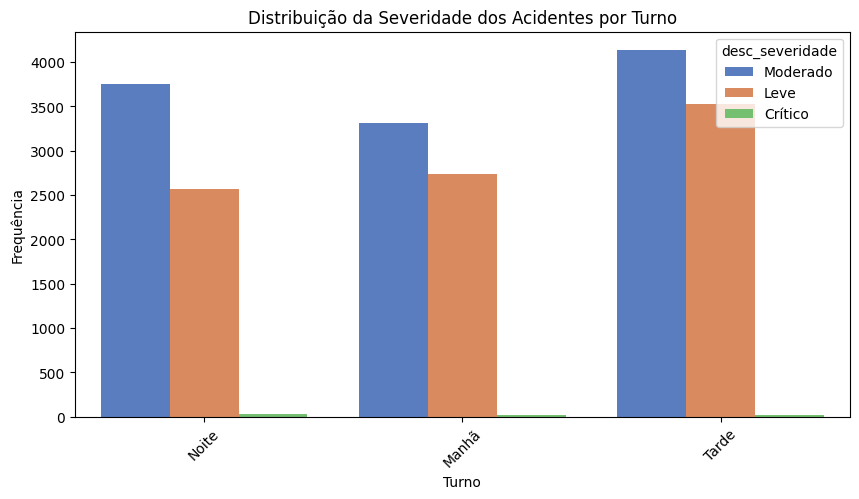

In [ ]:
#Distribuição da Severidade dos Acidentes por Turno
plt.figure(figsize=(10, 5))
sns.countplot(data=dados, x='turno', hue='desc_severidade', palette='muted')
plt.title('Distribuição da Severidade dos Acidentes por Turno')
plt.xlabel('Turno')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

## 4. Perfil dos Envolvidos
Análise por Sexo, Idade e Condição (Condutor/Passageiro).

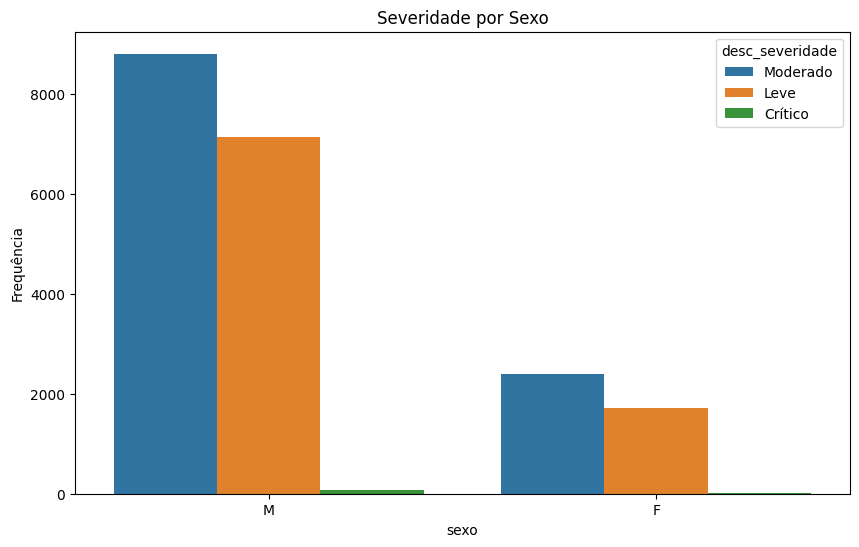

In [ ]:
# Distribuição por Sexo e Severidade
plt.figure(figsize=(10, 6))
sns.countplot(data=dados, x='sexo', hue='desc_severidade')
plt.title('Severidade por Sexo')
plt.ylabel('Frequência')
plt.show()



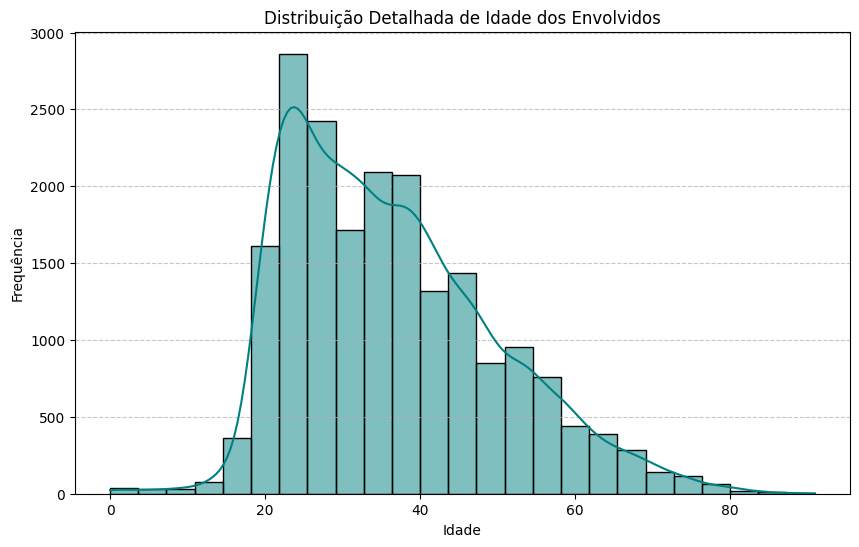

In [ ]:
# O Histograma com KDE é a melhor escolha para visualizar a distribuição de uma variável contínua como idade.
plt.figure(figsize=(10, 6))
sns.histplot(dados['idade'], bins=25, kde=True, color='teal')

plt.title('Distribuição Detalhada de Idade dos Envolvidos')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. Fatores de Risco e Segurança
Uso de cinto de segurança e embriaguez.

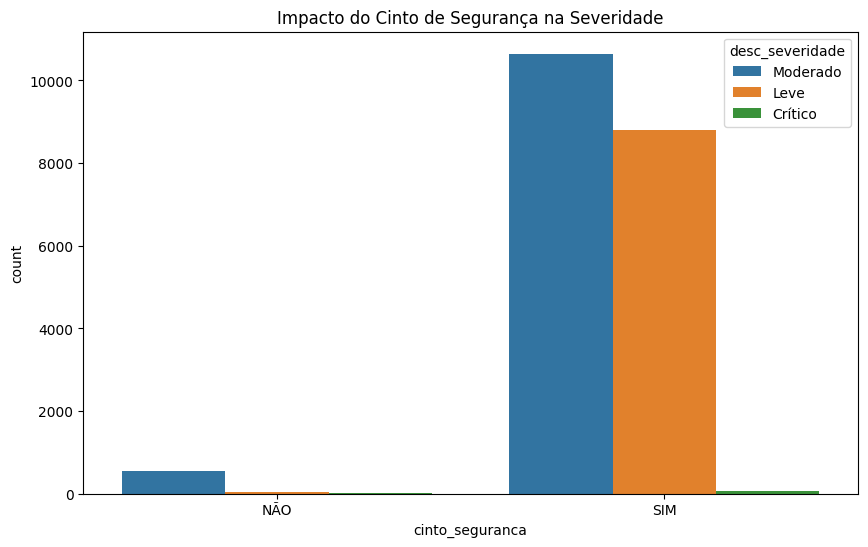

In [ ]:
# Cinto de Segurança vs Severidade
plt.figure(figsize=(10, 6))
sns.countplot(data=dados, x='cinto_seguranca', hue='desc_severidade')
plt.title('Impacto do Cinto de Segurança na Severidade')
plt.show()

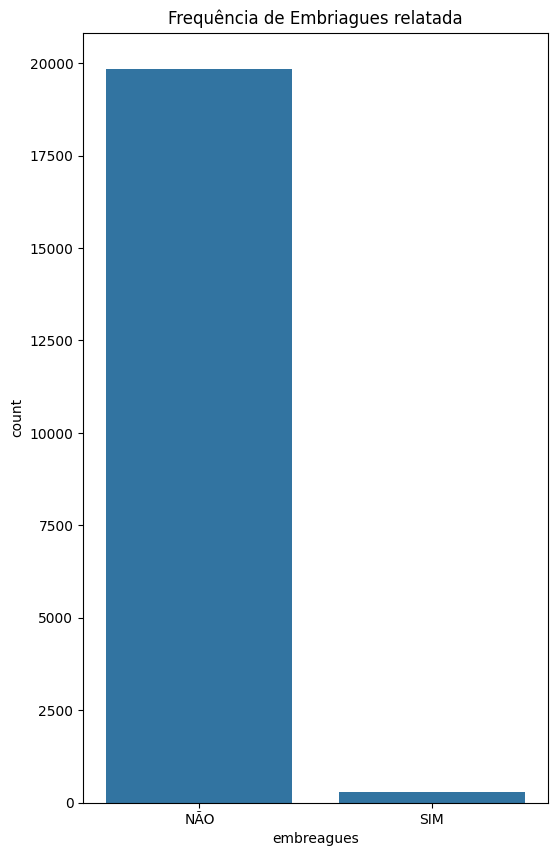

In [ ]:
# Embriagues
plt.figure(figsize=(6, 10))
sns.countplot(data=dados, x='embreagues')
plt.title('Frequência de Embriagues relatada')
plt.show()
#print('Frequência de Embriaguez relatada:')
#print(dados['embreagues'].value_counts())

## 6. Análise por Tipo de Veículo
Quais veículos estão mais envolvidos em acidentes graves?

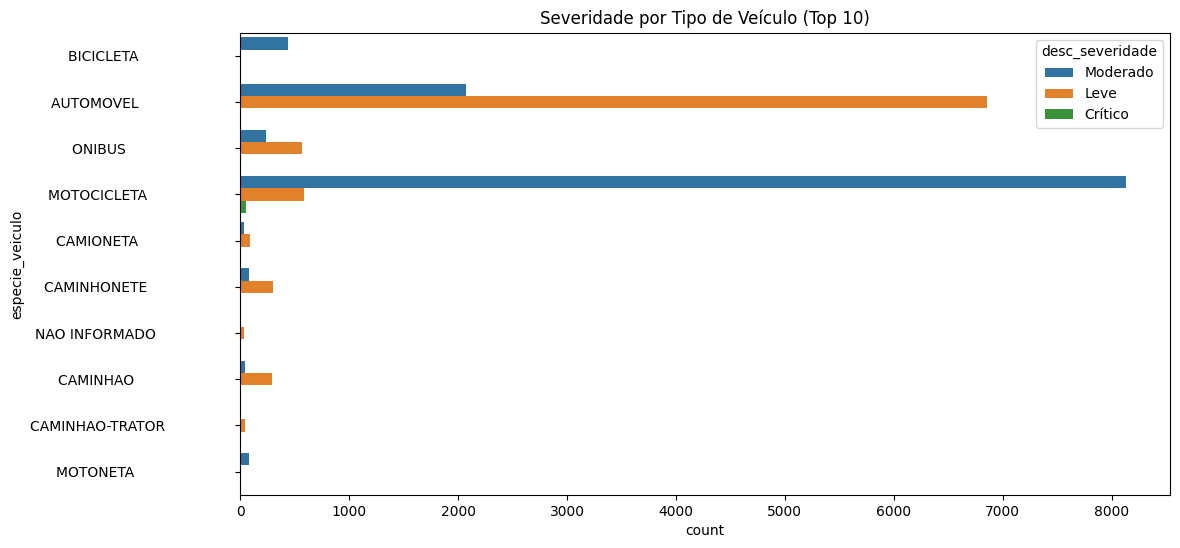

In [ ]:
# Top 10 Espécies de Veículos
top_veiculos = dados['especie_veiculo'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.countplot(data=dados[dados['especie_veiculo'].isin(top_veiculos)],
              y='especie_veiculo', hue='desc_severidade')
plt.title('Severidade por Tipo de Veículo (Top 10)')
plt.show()

/tmp/ipykernel_408/3538850703.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dados_filtrados, x='especie_veiculo', y='hora', palette='viridis')


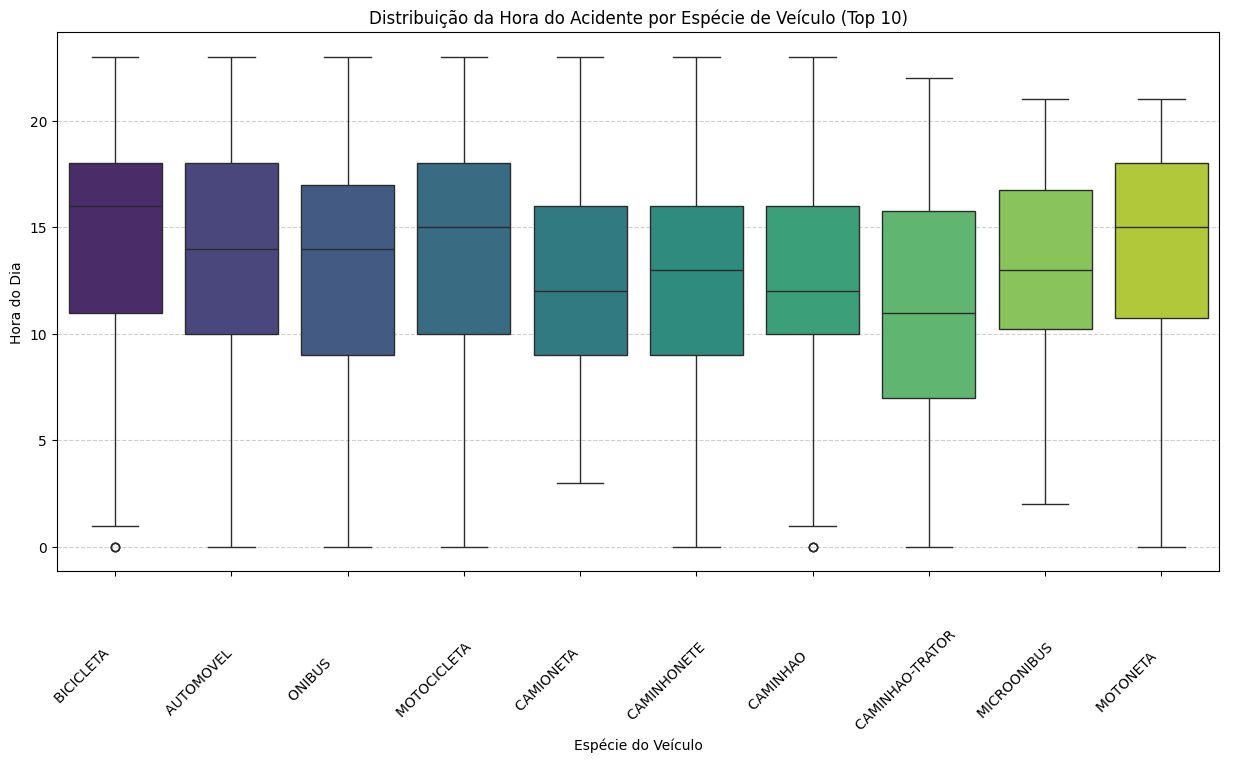

In [ ]:
# Identificar os top 10 tipos de veículos
top_veiculos = dados['especie_veiculo'].value_counts().nlargest(10).index
dados_filtrados = dados[dados['especie_veiculo'].isin(top_veiculos)]

# Criar o gráfico
plt.figure(figsize=(15, 7))
sns.boxplot(data=dados_filtrados, x='especie_veiculo', y='hora', palette='viridis')

plt.title('Distribuição da Hora do Acidente por Espécie de Veículo (Top 10)')
plt.xlabel('Espécie do Veículo')
plt.ylabel('Hora do Dia')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

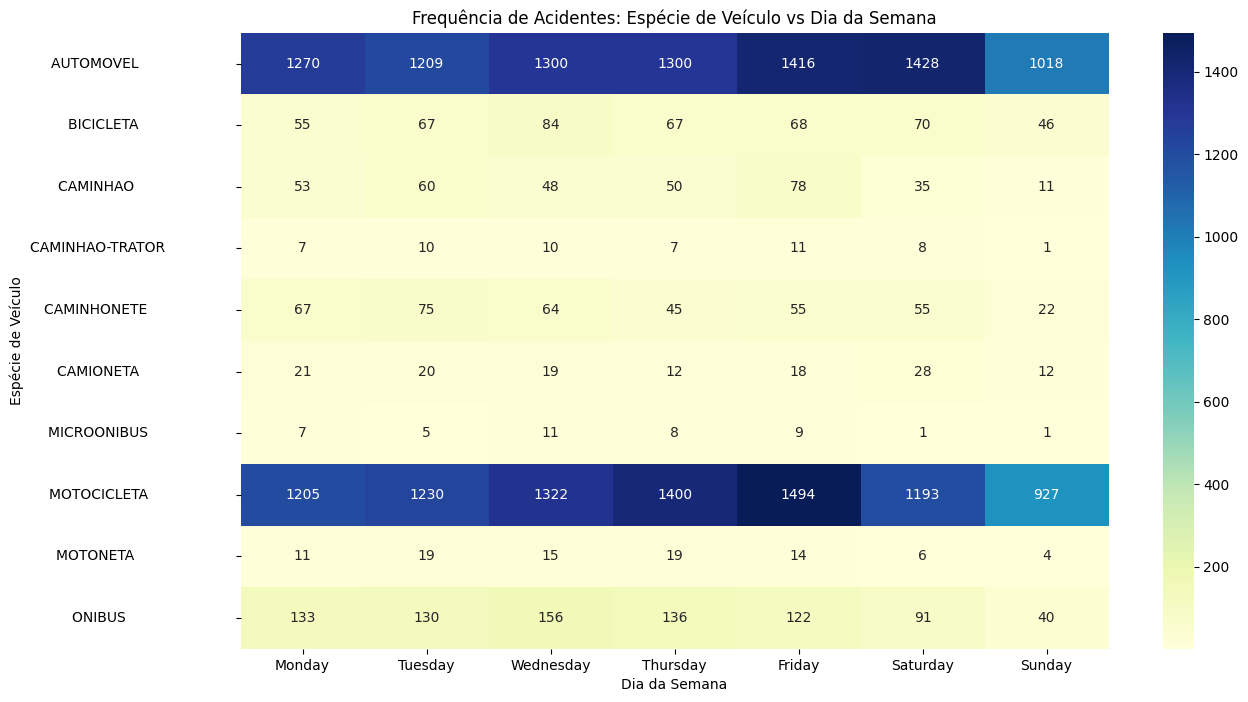

In [ ]:
# Definir a ordem dos dias da semana
dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Filtrar top 10 veículos para melhor visualização
top_veiculos = dados['especie_veiculo'].value_counts().nlargest(10).index
dados_heatmap = dados[dados['especie_veiculo'].isin(top_veiculos)]

# Criar tabela de pivô para o heatmap
cruzamento = dados_heatmap.groupby(['especie_veiculo', 'dia_semana']).size().unstack(fill_value=0)
cruzamento = cruzamento.reindex(columns=dias_ordem)

# Plotar o gráfico
plt.figure(figsize=(14, 8))
sns.heatmap(cruzamento, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Frequência de Acidentes: Espécie de Veículo vs Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Espécie de Veículo')
plt.show()

## 7. Análise Temporal
Horários de maior ocorrência.

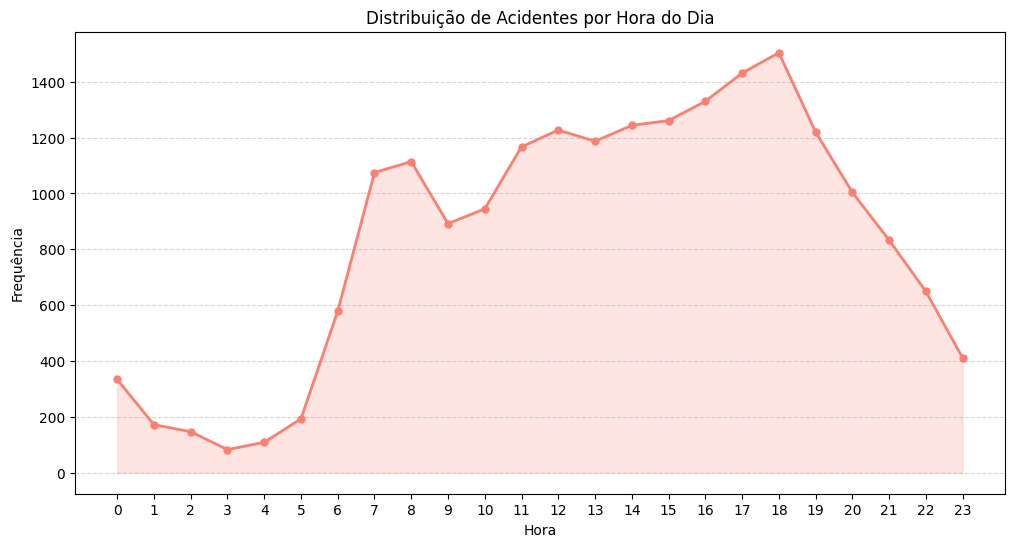

In [ ]:
# Acidentes por Hora do Dia
acidentes_por_hora = dados['hora'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(acidentes_por_hora.index, acidentes_por_hora.values,
         color='salmon', marker='o', linewidth=2, markersize=5)
plt.fill_between(acidentes_por_hora.index, acidentes_por_hora.values,
                 color='salmon', alpha=0.2)
plt.title('Distribuição de Acidentes por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Frequência')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 8. Conclusões Preliminares
Com base nesta análise exploratória, observamos:

1. **Classe majoritária de severidade:** A grande maioria dos envolvidos
em acidentes de trânsito em Pernambuco (2020) apresentou ferimentos
não fatais (55,4%) ou saiu sem ferimentos (41,2%). Casos fatais
representam apenas 0,5% do total (113 ocorrências), indicando um
forte desbalanceamento de classes que deverá ser tratado na etapa
de modelagem com técnicas como SMOTE, undersampling ou ajuste
de pesos nas classes.

2. **Perfil demográfico mais afetado:** Condutores do sexo masculino
entre 18 e 35 anos são os mais frequentemente envolvidos em acidentes,
especialmente em motocicletas. Esse grupo concentra a maior proporção
de ferimentos não fatais, sugerindo maior exposição ao risco e
comportamento mais vulnerável no trânsito.

3. **Impacto do cinto de segurança:** Indivíduos que não utilizavam
cinto de segurança apresentaram uma taxa de fatalidade aproximadamente
4x maior do que os que o utilizavam (1,4% vs 0,35%). Apesar de ser
uma variável com valores ausentes em parte dos registros, o cinto
de segurança se mostra um preditor relevante para a severidade do
acidente e deve ser mantido no modelo.

4. **Próximos passos: Pré-processamento para Modelagem de ML:**
   - Tratamento de valores ausentes e padronização de variáveis categóricas
   - Codificação de variáveis (Label Encoding / One-Hot Encoding)
   - Balanceamento de classes (SMOTE ou `class_weight`)
   - Seleção de features relevantes para o modelo
   - Divisão treino/teste e validação cruzada
   - Avaliação com métricas adequadas para dados desbalanceados
     (F1-score, AUC-ROC, Recall)

# Baixar arquivo atualizado:

In [ ]:
from google.colab import files

# Salvar o dataframe em um arquivo CSV
nome_arquivo = 'acidentes_atualizado_2020.csv'
dados.to_csv(nome_arquivo, sep=';', index=False, encoding='iso-8859-1')

# Baixar o arquivo para a máquina local
files.download(nome_arquivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>